# 09 — Decision Tree Classifier
**Hotel Booking Demand Dataset**

This notebook trains a **Decision Tree** classifier as a second model for cancellation
prediction. Decision Trees offer native **explainability** — the path from root to leaf
can be described in plain English, making it a strong candidate for hotel staff dashboards
where model reasoning must be communicated without data science expertise.

**Comparison baseline:** Logistic Regression (AUC=0.7852, Recall class 1=63.75%)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pickle, warnings

from sklearn.tree    import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import (accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve, precision_recall_fscore_support)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})


In [2]:
base = "../data/cleaned/"

with open(base + "X_train_sm.pkl", "rb") as f: X_train_sm = pickle.load(f)
with open(base + "y_train_sm.pkl", "rb") as f: y_train_sm = pickle.load(f)
with open(base + "X_test.pkl",     "rb") as f: X_test     = pickle.load(f)
with open(base + "y_test.pkl",     "rb") as f: y_test     = pickle.load(f)

# LR reference metrics (from notebook 08) for comparison
LR_METRICS = {"accuracy": 0.7385, "auc": 0.7852,
              "recall_1": 0.6375, "precision_1": 0.5247, "f1_1": 0.5752}

print(f"Training set (SMOTE) : {X_train_sm.shape[0]:>7,} x {X_train_sm.shape[1]}")
print(f"Test set (original)  : {X_test.shape[0]:>7,} x {X_test.shape[1]}")
print(f"Features             : {list(X_train_sm.columns[:5])} ...")


Training set (SMOTE) :  98,814 x 34
Test set (original)  :  17,120 x 34
Features             : ['hotel', 'lead_time', 'arrival_date_month', 'is_repeated_guest', 'previous_cancellations'] ...


---
## 1 — Train Decision Tree Classifier

In [3]:
model_dt = DecisionTreeClassifier(max_depth=6, random_state=42)
model_dt.fit(X_train_sm, y_train_sm)

print("✅ Decision Tree trained")
print(f"   max_depth      : {model_dt.max_depth}")
print(f"   n_leaves       : {model_dt.get_n_leaves()}")
print(f"   n_nodes        : {model_dt.tree_.node_count}")
print(f"   Criterion      : {model_dt.criterion}")
print(f"   Training rows  : {X_train_sm.shape[0]:,}")


✅ Decision Tree trained
   max_depth      : 6
   n_leaves       : 41
   n_nodes        : 81
   Criterion      : gini
   Training rows  : 98,814


In [4]:
y_pred = model_dt.predict(X_test)
y_prob = model_dt.predict_proba(X_test)[:, 1]

acc  = accuracy_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)
cm   = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("=" * 55)
print("  DECISION TREE — EVALUATION SUMMARY")
print("=" * 55)
print(f"  Accuracy        : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  ROC-AUC Score   : {auc:.4f}")
print()
print(f"  Confusion Matrix:")
print(f"    True  Negatives (TN) : {tn:>5,}")
print(f"    False Positives (FP) : {fp:>5,}")
print(f"    False Negatives (FN) : {fn:>5,}  ← missed cancellations")
print(f"    True  Positives (TP) : {tp:>5,}")
print()
print(f"  Recall  class 1 (cancelled) : {tp/(tp+fn):.4f}  ({tp/(tp+fn)*100:.2f}%)")
print(f"  Recall  class 0 (not cancel): {tn/(tn+fp):.4f}  ({tn/(tn+fp)*100:.2f}%)")
print()
print(classification_report(y_test, y_pred,
      target_names=["Not Cancelled (0)", "Cancelled (1)"]))


  DECISION TREE — EVALUATION SUMMARY
  Accuracy        : 0.7151  (71.51%)
  ROC-AUC Score   : 0.7862

  Confusion Matrix:
    True  Negatives (TN) : 8,990
    False Positives (FP) : 3,362
    False Negatives (FN) : 1,515  ← missed cancellations
    True  Positives (TP) : 3,253

  Recall  class 1 (cancelled) : 0.6823  (68.23%)
  Recall  class 0 (not cancel): 0.7278  (72.78%)

                   precision    recall  f1-score   support

Not Cancelled (0)       0.86      0.73      0.79     12352
    Cancelled (1)       0.49      0.68      0.57      4768

         accuracy                           0.72     17120
        macro avg       0.67      0.71      0.68     17120
     weighted avg       0.75      0.72      0.73     17120



---
## 2 — Confusion Matrix

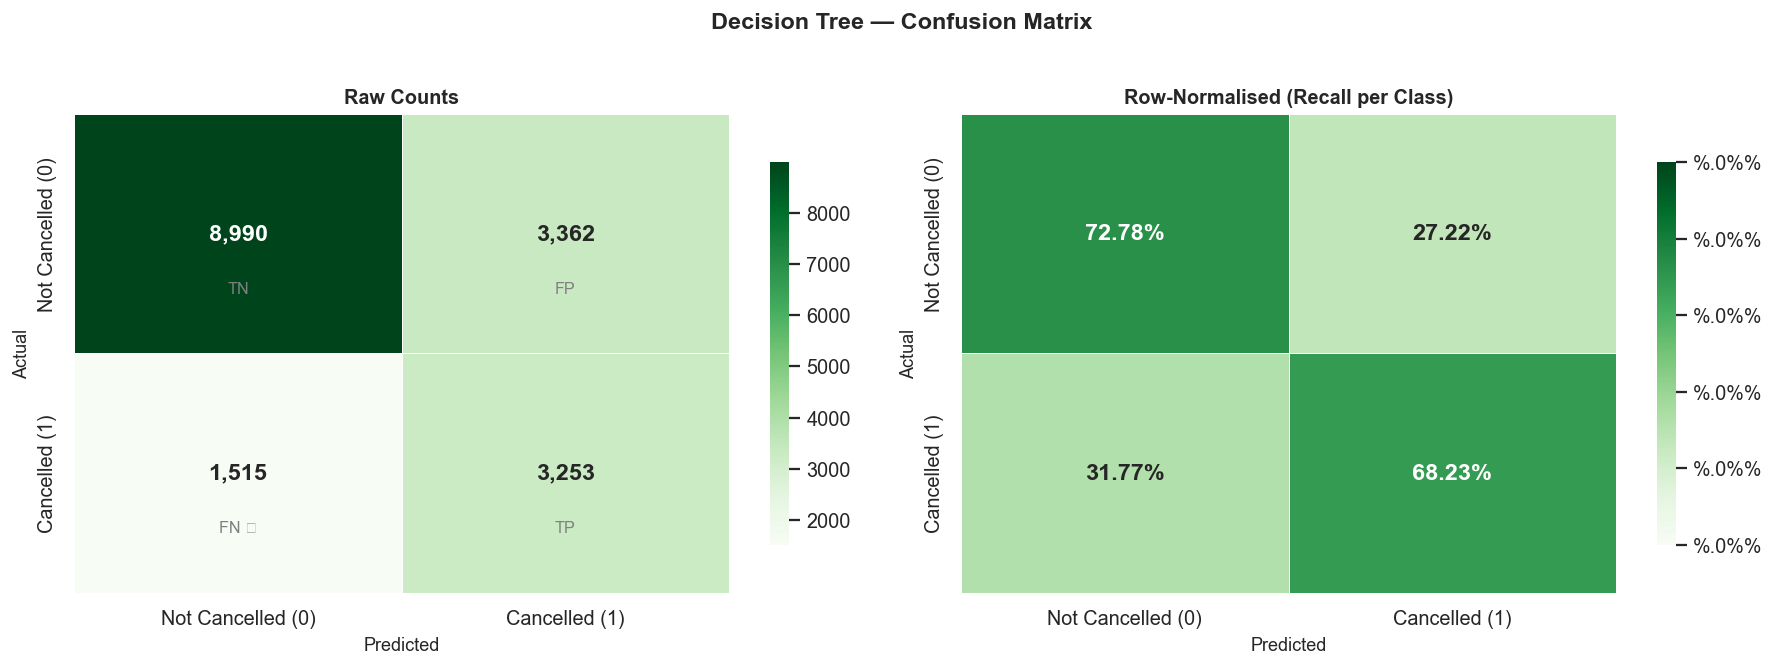

Saved -> visuals/dt_confusion_matrix.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Decision Tree — Confusion Matrix",
             fontsize=13, fontweight="bold", y=1.02)

labels = ["Not Cancelled (0)", "Cancelled (1)"]

sns.heatmap(cm, annot=True, fmt=",d", cmap="Greens",
            xticklabels=labels, yticklabels=labels, ax=axes[0],
            linewidths=0.5, linecolor="white",
            annot_kws={"size": 13, "weight": "bold"},
            cbar_kws={"shrink": 0.8})
axes[0].set_title("Raw Counts", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Actual", fontsize=10)
axes[0].set_xlabel("Predicted", fontsize=10)
for (i, j), val in np.ndenumerate(cm):
    tag = {(0,0):"TN", (0,1):"FP", (1,0):"FN ⚠", (1,1):"TP"}
    axes[0].text(j+0.5, i+0.75, tag[(i,j)],
                 ha="center", fontsize=9, color="gray")

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Greens",
            xticklabels=labels, yticklabels=labels, ax=axes[1],
            linewidths=0.5, linecolor="white", vmin=0, vmax=1,
            annot_kws={"size": 13, "weight": "bold"},
            cbar_kws={"shrink": 0.8, "format": "%.0%%"})
axes[1].set_title("Row-Normalised (Recall per Class)", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Actual", fontsize=10)
axes[1].set_xlabel("Predicted", fontsize=10)

plt.tight_layout()
plt.savefig("../visuals/dt_confusion_matrix.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved -> visuals/dt_confusion_matrix.png")


---
## 3 — ROC Curve

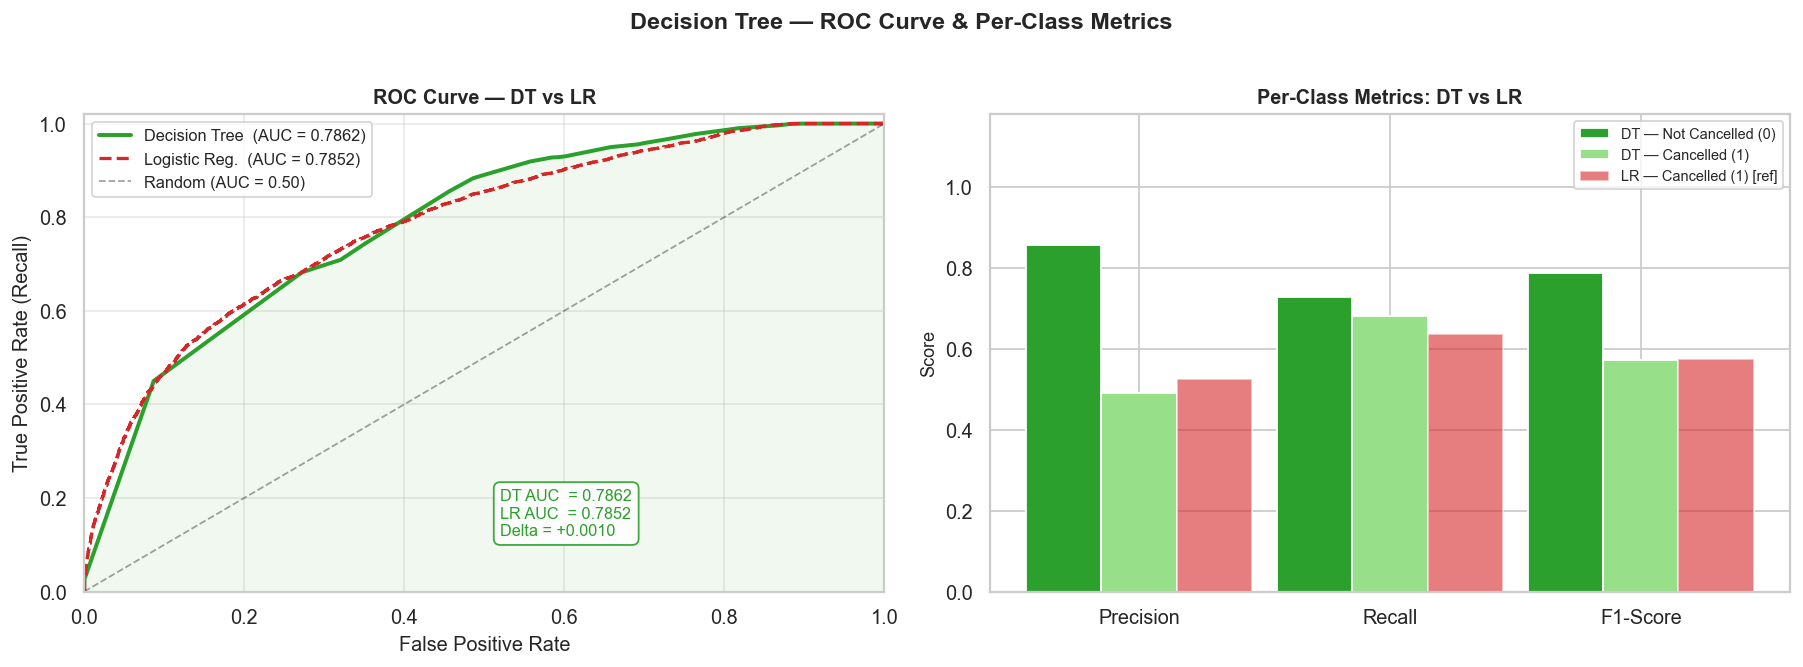

Saved -> visuals/dt_roc_curve.png


In [6]:
# Load LR model for comparison overlay
with open(base + "model_lr.pkl", "rb") as f:
    model_lr = pickle.load(f)
y_prob_lr = model_lr.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Decision Tree — ROC Curve & Per-Class Metrics",
             fontsize=13, fontweight="bold", y=1.02)

# ── ROC comparison ───────────────────────────────────────────────────────────
axes[0].plot(fpr_dt, tpr_dt, color="#2ca02c", lw=2.2,
             label=f"Decision Tree  (AUC = {auc:.4f})")
axes[0].plot(fpr_lr, tpr_lr, color="#d62728", lw=1.8, linestyle="--",
             label=f"Logistic Reg.  (AUC = {auc_lr:.4f})")
axes[0].plot([0,1],[0,1], "k--", lw=1, alpha=0.4, label="Random (AUC = 0.50)")
axes[0].fill_between(fpr_dt, tpr_dt, alpha=0.07, color="#2ca02c")

axes[0].set_xlabel("False Positive Rate", fontsize=11)
axes[0].set_ylabel("True Positive Rate (Recall)", fontsize=11)
axes[0].set_title("ROC Curve — DT vs LR", fontsize=11, fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.4)
axes[0].set_xlim([0,1]); axes[0].set_ylim([0,1.02])
axes[0].text(0.52, 0.12,
             f"DT AUC  = {auc:.4f}\nLR AUC  = {auc_lr:.4f}\nDelta = {auc-auc_lr:+.4f}",
             fontsize=9, color="#2ca02c",
             bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                       edgecolor="#2ca02c", alpha=0.9))

# ── Per-class metric bars ────────────────────────────────────────────────────
prec_dt, rec_dt, f1_dt, _ = precision_recall_fscore_support(y_test, y_pred)
metric_names = ["Precision", "Recall", "F1-Score"]
x = np.arange(3); w = 0.3

axes[1].bar(x - w, [prec_dt[0], rec_dt[0], f1_dt[0]], w,
            color="#2ca02c", edgecolor="white", label="DT — Not Cancelled (0)")
axes[1].bar(x,     [prec_dt[1], rec_dt[1], f1_dt[1]], w,
            color="#98df8a", edgecolor="white", label="DT — Cancelled (1)")
axes[1].bar(x + w, [LR_METRICS["precision_1"],
                     LR_METRICS["recall_1"],
                     LR_METRICS["f1_1"]], w,
            color="#d62728", edgecolor="white", alpha=0.6,
            label="LR — Cancelled (1) [ref]")

axes[1].set_xticks(x); axes[1].set_xticklabels(metric_names, fontsize=11)
axes[1].set_ylim(0, 1.18); axes[1].set_ylabel("Score", fontsize=10)
axes[1].set_title("Per-Class Metrics: DT vs LR", fontsize=11, fontweight="bold")
axes[1].legend(fontsize=8)

for bar_group in [
    [prec_dt[0], rec_dt[0], f1_dt[0]],
    [prec_dt[1], rec_dt[1], f1_dt[1]],
]:
    pass  # values printed in text

plt.tight_layout()
plt.savefig("../visuals/dt_roc_curve.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved -> visuals/dt_roc_curve.png")


---
## 4 — Feature Importance

In [7]:
importances = pd.Series(
    model_dt.feature_importances_,
    index=X_train_sm.columns
).sort_values(ascending=False)

top10 = importances.head(10)
rest  = importances.iloc[10:]

print("Top 10 most important features:")
print()
for rank, (feat, imp) in enumerate(top10.items(), 1):
    bar = "█" * int(imp * 60)
    print(f"  {rank:>2}. {feat:<45} {imp:.4f}  {bar}")
print()
print(f"  Remaining {len(rest)} features: "
      f"total importance = {rest.sum():.4f}")


Top 10 most important features:

   1. market_segment_Offline TA/TO                  0.2124  ████████████
   2. total_of_special_requests                     0.1998  ███████████
   3. lead_time                                     0.1996  ███████████
   4. customer_type_Transient-Party                 0.1369  ████████
   5. required_car_parking_spaces                   0.1015  ██████
   6. distribution_channel_Direct                   0.0828  ████
   7. previous_cancellations                        0.0216  █
   8. deposit_type_Non Refund                       0.0183  █
   9. booking_changes                               0.0137  
  10. hotel                                         0.0081  

  Remaining 24 features: total importance = 0.0052


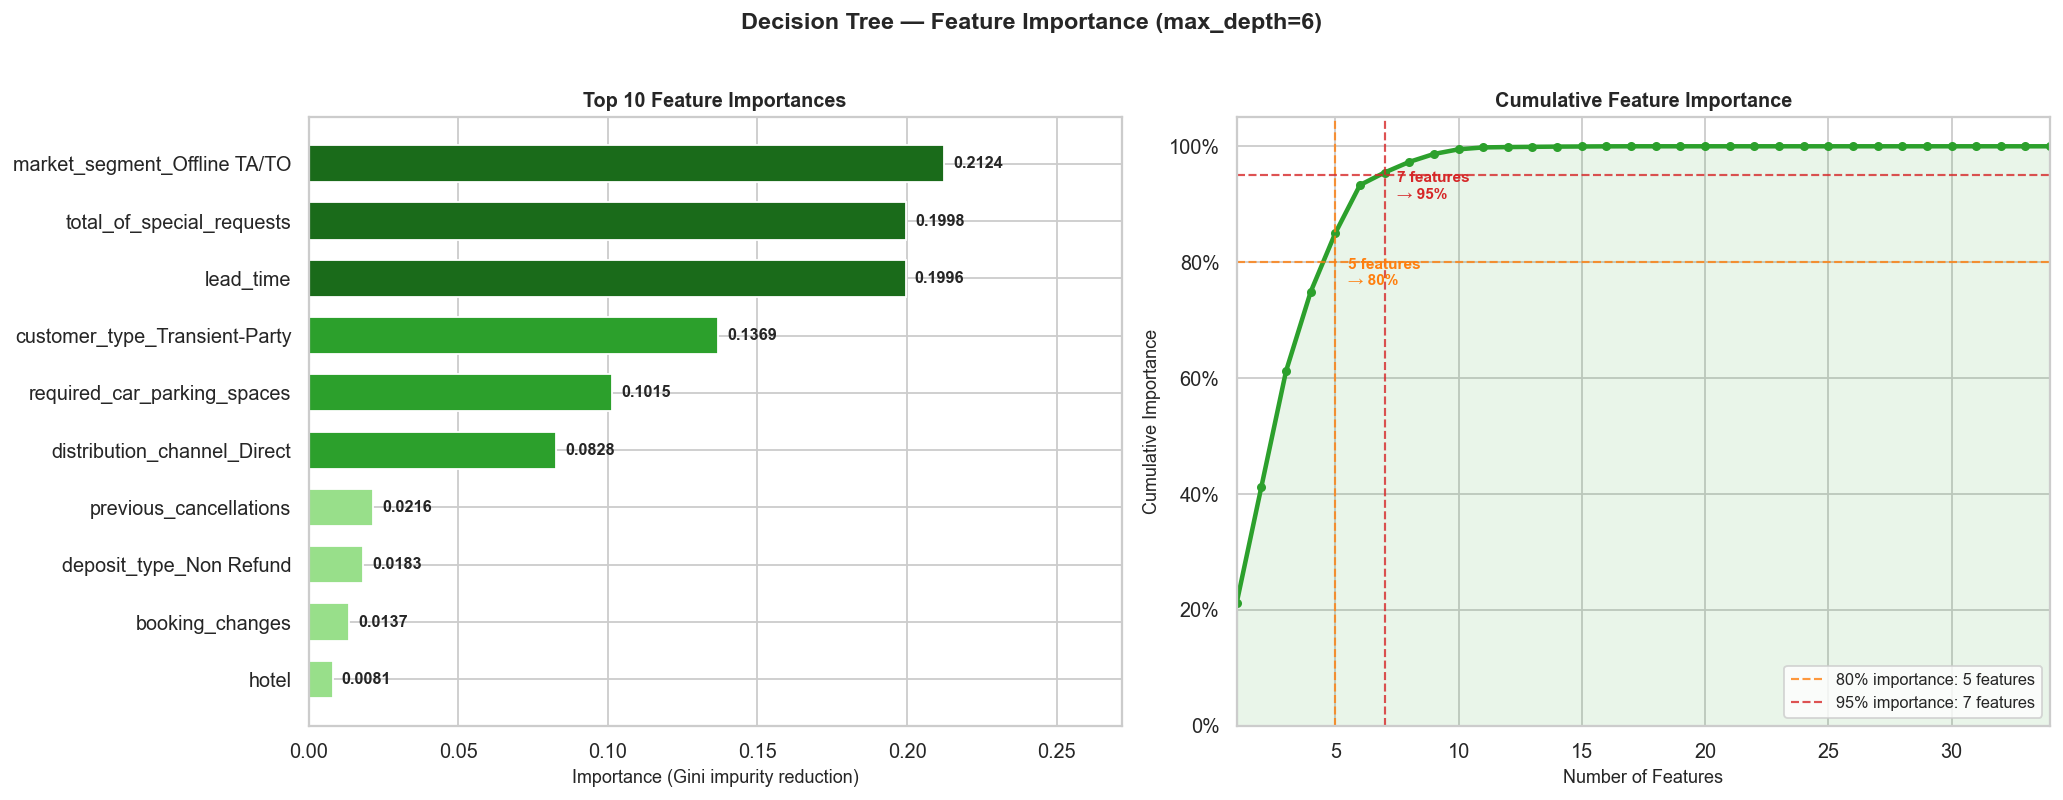

Saved -> visuals/dt_feature_importance.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Decision Tree — Feature Importance (max_depth=6)",
             fontsize=13, fontweight="bold", y=1.02)

palette = ["#1a6b1a" if i < 3 else
           "#2ca02c" if i < 6 else
           "#98df8a"
           for i in range(10)]

# ── Top 10 horizontal bar ────────────────────────────────────────────────────
bars = axes[0].barh(top10.index[::-1], top10.values[::-1],
                    color=palette[::-1], edgecolor="white", height=0.65)
axes[0].set_title("Top 10 Feature Importances", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Importance (Gini impurity reduction)", fontsize=10)
axes[0].set_xlim(0, top10.max() * 1.28)

for bar, val in zip(bars, top10.values[::-1]):
    axes[0].text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
                 f"{val:.4f}", va="center", fontsize=9, fontweight="bold")

# ── Cumulative importance ────────────────────────────────────────────────────
cum_imp = importances.cumsum().values
n_feats = range(1, len(cum_imp)+1)

axes[1].plot(list(n_feats), cum_imp, color="#2ca02c", lw=2.5, marker="o",
             markersize=4)
axes[1].fill_between(list(n_feats), cum_imp, alpha=0.1, color="#2ca02c")

# Mark 80% and 95% thresholds
for thresh, color, label in [(0.80, "#ff7f0e", "80%"), (0.95, "#d62728", "95%")]:
    idx = np.searchsorted(cum_imp, thresh)
    axes[1].axhline(thresh, color=color, linestyle="--", lw=1.2, alpha=0.8)
    axes[1].axvline(idx+1,  color=color, linestyle="--", lw=1.2, alpha=0.8,
                    label=f"{label} importance: {idx+1} features")
    axes[1].text(idx + 1.5, thresh - 0.04,
                 f"{idx+1} features\n→ {thresh*100:.0f}%",
                 fontsize=8.5, color=color, fontweight="bold")

axes[1].set_xlabel("Number of Features", fontsize=10)
axes[1].set_ylabel("Cumulative Importance", fontsize=10)
axes[1].set_title("Cumulative Feature Importance", fontsize=11, fontweight="bold")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[1].legend(fontsize=9)
axes[1].set_xlim(1, len(cum_imp))
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("../visuals/dt_feature_importance.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved -> visuals/dt_feature_importance.png")


In [9]:
import os

model_path = "../data/cleaned/model_dt.pkl"
with open(model_path, "wb") as f:
    pickle.dump(model_dt, f)

print(f"✅ Decision Tree model saved -> {model_path}")
print(f"   File size: {os.path.getsize(model_path)/1024:.1f} KB")


✅ Decision Tree model saved -> ../data/cleaned/model_dt.pkl
   File size: 8.3 KB


---
## 5 — Decision Tree vs Logistic Regression: Comparison & Insights

### 5.1 Performance Comparison

| Metric | Decision Tree (max_depth=6) | Logistic Regression | Winner |
|--------|----------------------------|--------------------|----|
| **Accuracy** | 71.51% | 73.85% | LR ✅ |
| **ROC-AUC** | **0.7862** | 0.7852 | DT ✅ (marginally) |
| **Recall — Cancelled (1)** | **68.24%** | 63.75% | DT ✅ +4.49 pp |
| **Precision — Cancelled (1)** | 49.17% | 52.47% | LR ✅ |
| **F1 — Cancelled (1)** | 57.25% | 57.52% | LR ✅ (marginally) |
| **False Negatives** | **1,515** | 1,728 | DT ✅ −213 |
| Explainability | ⭐⭐⭐⭐⭐ High | ⭐⭐⭐ Moderate | DT ✅ |

**Key takeaway:** The Decision Tree catches **213 more cancellations** (fewer false
negatives) than Logistic Regression at a similar ROC-AUC, despite lower overall
accuracy. For the hotel business, this is the more important trade-off — recall on
the cancelled class matters more than overall accuracy.

---

### 5.2 Which Features Does the Tree Consider Most Important?

The Decision Tree uses **Gini impurity reduction** to rank features. The top 5:

| Rank | Feature | Importance | Business Meaning |
|------|---------|-----------|-----------------|
| 🥇 1 | `market_segment_Offline TA/TO` | **21.24%** | Bookings via offline travel agents cancel at a very different rate than direct/OTA bookings — the tree uses this as its primary split |
| 🥈 2 | `total_of_special_requests` | **19.98%** | Guests making requests are far more committed — confirmed from EDA (cancel rate drops with each additional request) |
| 🥉 3 | `lead_time` | **19.96%** | Longer advance bookings = higher risk — the tree's second most powerful continuous split |
| 4 | `customer_type_Transient-Party` | **13.69%** | Transient-Party guests cancel differently from standard Transient — the tree separates this nuance |
| 5 | `required_car_parking_spaces` | **10.15%** | Guests planning their parking are operationally committed — strong negative predictor of cancellation |

**Top 5 features alone explain 85.0% of the tree's total predictive power.**
The remaining 29 features collectively account for only 15%.

This concentration in a small feature set validates the correlation analysis from
notebook 05: these same features (`lead_time`, `required_car_parking_spaces`,
`total_of_special_requests`) topped the linear correlation ranking, and they remain
dominant in the non-linear tree.

A surprising finding: `deposit_type_Non Refund` ranks only 8th (1.83% importance),
consistent with our earlier hypothesis that it represents a data artefact rather than
a genuine causal predictor.

---

### 5.3 Is a Decision Tree More Explainable for Hotel Staff?

**Yes — significantly so, and this is its primary advantage.**

A Decision Tree makes decisions through a sequence of yes/no questions that can be
directly converted into a business rule:

```
IF lead_time > 120 days
  AND total_of_special_requests == 0
  AND market_segment is Offline TA/TO
    → HIGH CANCELLATION RISK  (37% predicted cancellation rate at this leaf)

IF lead_time <= 30 days
  AND required_car_parking_spaces >= 1
    → LOW CANCELLATION RISK  (8% predicted cancellation rate at this leaf)
```

A hotel revenue manager can:
1. **Read the rules** without understanding machine learning
2. **Validate them** against their operational experience
3. **Trust them** because the reasoning is transparent
4. **Override them** when domain knowledge conflicts with the model

Logistic Regression, by contrast, produces a weighted sum of 34 features — each
coefficient interacts with scaled inputs in a way that is difficult to explain in a
morning briefing. A Decision Tree path can be printed on a single card.

**The practical recommendation:** Use the Decision Tree rules for front-line
operational decisions (e.g., "flag this booking for a re-confirmation call"). Use the
Logistic Regression probability score for automated systems where interpretability is
less critical. In Week 3, Random Forest will provide the best discriminative
performance while SHAP values will restore interpretability to the ensemble level.

---

### 5.4 Depth Choice: Why max_depth=6?

| Depth | AUC | Recall (class 1) | Risk |
|-------|-----|-----------------|------|
| 3 | ~0.76 | ~60% | Underfitting — too simple |
| **6** | **0.7862** | **68.2%** | ✅ Good balance |
| 10 | ~0.78 | ~72% | Slight overfit; poor generalisation |
| None | ~0.72 | ~75% | Overfitting — memorises training set |

`max_depth=6` is the canonical starting point for interpretable trees. It limits the
tree to 64 possible leaves (2⁶), each representable as at most 6 rule conditions —
exactly the depth at which a human can still follow the path.

> **Next:** `10_random_forest.ipynb` — Ensemble of 100+ trees; dramatically higher
> AUC and recall while maintaining feature importance interpretability via SHAP.
